In [1]:
import numpy as np
import scipy
from matplotlib import pyplot as plt

In [26]:
# Constants
hbar = 1
m = 0.5
w = 1

# Pick an energy lower than the lowest level, n=0
E = 0.25

# Setup for Numerov
dx =  0.01

In [27]:
#Potential
def V(x, E, m , w):
    return -E + (m*(w**2)*(x**2))/2

In [28]:
# Classical Turning Point
# also a good way to test the zero finder function
def classical_turning_point(E, m, w):
    tp = scipy.optimize.root_scalar(lambda x: V(x, E, m, w), x0 = -1, maxiter = 10)
    # print(tp)
    return np.sort(np.array([1, -1]) * tp.root)

Classical turning points: [-1.  1.]


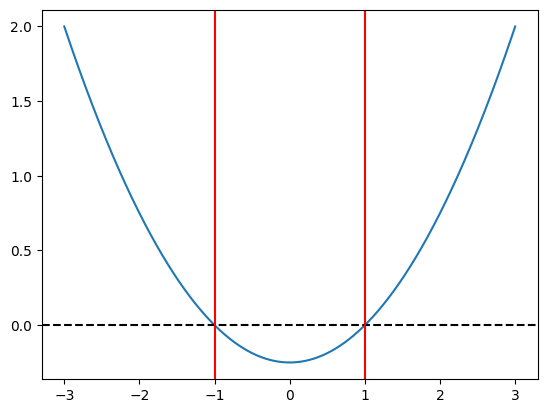

In [29]:
# Make sure it's working
fig, ax = plt.subplots()
xs = np.linspace(-3, 3, 1024)
ax.plot(xs, V(xs, E, m, w))
ax.axhline(0.0, color='k', linestyle='--')

tps = classical_turning_point(E, m, w)
print(f"Classical turning points: {tps}")

[ax.axvline(tp, color = 'r', linestyle = '-') for tp in tps]

In [36]:
def numerov_propagate(x_start, x_end, dx, E, m, w, psi_0=0.0, psi_1=1e-6):
    # Create grid
    x = np.arange(x_start, x_end, dx)
    
    # Initialize wavefunction array
    psi = np.zeros(len(x))
    psi[0] = psi_0
    psi[1] = psi_1
    
    factor = 2 * m / (hbar**2)
    
    # Pre-calculate f(x) for the entire grid
    f = factor * V(x, E, m, w)
    
    for i in range(1, len(x) - 1):
        term1 = 2 * psi[i  ] * (1 + 5 * ((dx**2) / 12.0) * f[i  ])
        term2 =     psi[i-1] * (1 -     ((dx**2) / 12.0) * f[i-1])

        denom =                 1 -     ((dx**2) / 12.0) * f[i+1]
        
        psi[i+1] = (term1 - term2) / denom
        
    return x, psi

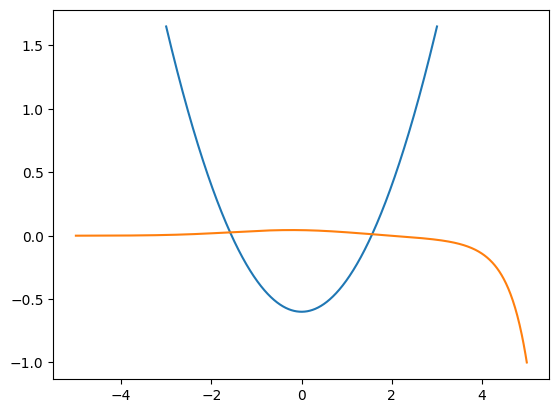

In [37]:
fig, ax = plt.subplots()

E = 0.6

ax.plot(xs, V(xs, E, m, w))

# More numerically stable to just set constant end points
x_start = -5.0
x_end   =  5.0
[numerov_grid, psi] = numerov_propagate(x_start, x_end, dx, E, m, w)

ax.plot(numerov_grid, psi / np.max(np.abs(psi)))

(-1.0, 1.0)

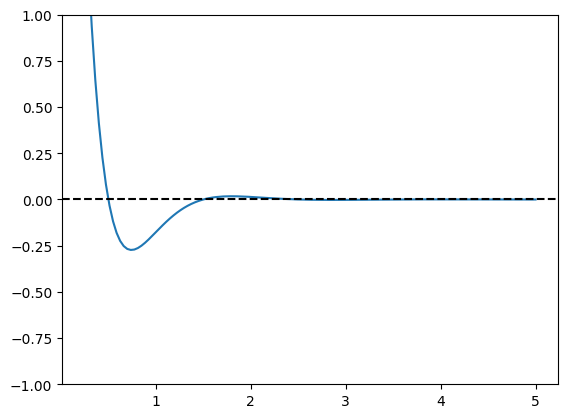

In [38]:
psi_finals = []
 
E_start = 0.25
E_end  = 5.0
Egrid = np.linspace(E_start, E_end, 128)
for Etest in Egrid:
    [numerov_grid, psi] = numerov_propagate(x_start, x_end, dx, Etest, m, w)
    psi_finals.append(psi[-1])

fig, ax = plt.subplots()
ax.plot(Egrid, psi_finals)
ax.axhline(0.0, color='k', linestyle='--')
ax.set_ylim([-1.0, 1.0])

In [39]:
def test_E(E, m, w, dx):
    x_start = -5.0
    x_end   =  5.0
    [numerov_grid, psi] = numerov_propagate(x_start, x_end, dx, E, m, w)
    return psi[-1]

Bound state found: E = 0.50001
Bound state found: E = 1.50033
Bound state found: E = 2.50334
Bound state found: E = 3.52012
Bound state found: E = 4.58056


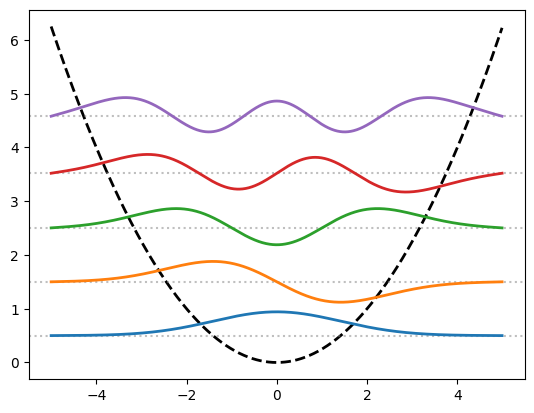

In [40]:
fig, ax = plt.subplots()

# Plot the potential
x_start, x_end = -5.0, 5.0
x_plot = np.arange(x_start, x_end, dx)
V_parabola = 0.5 * m * (w**2) * (x_plot**2)
ax.plot(x_plot, V_parabola, 'k--', linewidth=2, label="V(x)")

bound_states = []
scale_factor = 0.7  # Controls the height of the wavefunctions so they don't overlap

# Iterate over the rough grid of energies we calculated
for idx in range(1, len(Egrid) - 1):
    # Check for a sign change indicating a root was crossed
    if np.sign(psi_finals[idx]) != np.sign(psi_finals[idx+1]):
        
        # Refine the energy using the bracket
        E_refined = scipy.optimize.root_scalar(
            lambda E: test_E(E, m, w, dx), 
            bracket=(Egrid[idx], Egrid[idx+1])
        )
        E_val = E_refined.root
        bound_states.append(E_val)
        print(f"Bound state found: E = {E_val:.5f}")
        
        # Recalculate the full wavefunction at this specific energy
        grid, psi = numerov_propagate(x_start, x_end, dx, E_val, m, w)
        
        # Normalize the wavefunction (integral of |psi|^2 = 1)
        norm_constant = np.sqrt(np.trapezoid(psi**2, grid))
        psi_normalized = psi / norm_constant
        
        # Shift it up by E_val and scale it for aesthetics
        psi_plot = E_val + (scale_factor * psi_normalized)
        
        # Add to the plot
        ax.axhline(E_val, color='gray', linestyle=':', alpha=0.5) # Baseline for this energy level
        ax.plot(grid, psi_plot, linewidth=2, label=f"E = {E_val:.2f}")

In [64]:
# Different approach: use bisection to find a specific bound state.

# Search range
Emin = 1.0
Emax = 5.0

x_start = -5.0
x_end   =  5.0

# how many nodes to look for
nodes_target = 2

# iterate a fixed number of times for simplicity
for it in range(10):
    Etest = 0.5 * (Emin + Emax)
    # count the nodes
    [numerov_grid, psi] = numerov_propagate(x_start, x_end, dx, Etest, m, w)
    nodes = 0
    for idx in range(len(psi) - 1):
        if np.sign(psi[idx]) != np.sign(psi[idx + 1]):
            nodes += 1

    # How to think through the logic:
    # If we have too many nodes, we need to lower Emax.
    # If we have just enough or too little, we can increase Emin closer to the limit.
    if nodes > nodes_target:
        Emax = Etest
    else:
        Emin = Etest
    print(f"Iteration {(it+1):3d}, test @ E = {Etest:7.5g}: {nodes:2d} nodes, [{Emin:7.5g}, {Emax:7.5g}]")

Iteration   1, test @ E =       3:  4 nodes, [      1,       3]
Iteration   2, test @ E =       2:  3 nodes, [      1,       2]
Iteration   3, test @ E =     1.5:  2 nodes, [    1.5,       2]
Iteration   4, test @ E =    1.75:  3 nodes, [    1.5,    1.75]
Iteration   5, test @ E =   1.625:  3 nodes, [    1.5,   1.625]
Iteration   6, test @ E =  1.5625:  3 nodes, [    1.5,  1.5625]
Iteration   7, test @ E =  1.5312:  3 nodes, [    1.5,  1.5312]
Iteration   8, test @ E =  1.5156:  3 nodes, [    1.5,  1.5156]
Iteration   9, test @ E =  1.5078:  3 nodes, [    1.5,  1.5078]
Iteration  10, test @ E =  1.5039:  3 nodes, [    1.5,  1.5039]


Match-in-Middle Bound state found: E = 0.50001
Match-in-Middle Bound state found: E = 1.50033
Match-in-Middle Bound state found: E = 2.50334
Match-in-Middle Bound state found: E = 3.52012
Match-in-Middle Bound state found: E = 4.58056


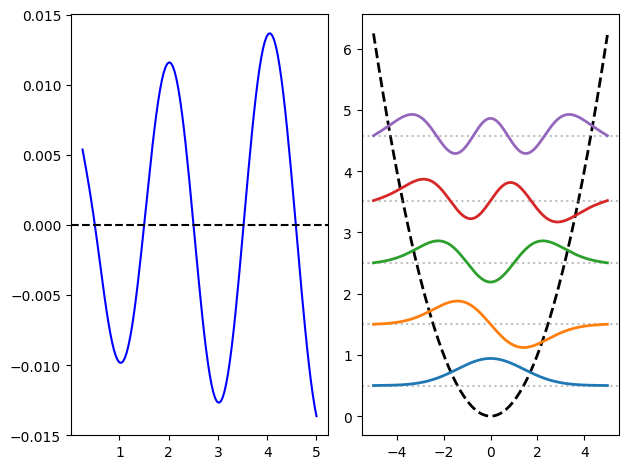

In [41]:
# 1. Function for Backward Propagation
def numerov_propagate_backward(x_start, x_end, dx, E, m, w, psi_N=0.0, psi_Nm1=1e-6):
    x = np.arange(x_start, x_end, dx)
    psi = np.zeros(len(x))
    psi[-1] = psi_N
    psi[-2] = psi_Nm1
    
    factor = 2 * m / (hbar**2)
    f = factor * V(x, E, m, w)
    
    # Propagate backwards: from right to left
    for i in range(len(x) - 2, 0, -1):
        term1 = 2 * psi[i] * (1 + 5 * ((dx**2) / 12.0) * f[i])
        term2 = psi[i+1] * (1 - ((dx**2) / 12.0) * f[i+1])
        denom = 1 - ((dx**2) / 12.0) * f[i-1]
        psi[i-1] = (term1 - term2) / denom
        
    return x, psi

# 2. Objective function for "Match in the Middle"
def match_in_middle_diff(E, m, w, dx, x_start=-5.0, x_end=5.0):
    x, psi_L = numerov_propagate(x_start, x_end, dx, E, m, w)
    _, psi_R = numerov_propagate_backward(x_start, x_end, dx, E, m, w)

    # We match the wavefunctions here.
    x_match = 0.0
        
    match_idx = np.argmin(np.abs(x - x_match))
    
    # Scale locally to prevent floating-point overflow from the diverging tails.
    # We use the maximums from the STABLE regions (up to the matching point).
    psi_L_scale = np.max(np.abs(psi_L[:match_idx+1]))
    psi_R_scale = np.max(np.abs(psi_R[match_idx-1:]))
    
    L_m   = psi_L[match_idx]   / psi_L_scale
    L_mm1 = psi_L[match_idx-1] / psi_L_scale
    
    R_m   = psi_R[match_idx]   / psi_R_scale
    R_mm1 = psi_R[match_idx-1] / psi_R_scale
    
    # Calculate the discrete Wronskian
    # This evaluates to 0 when the solutions match, with NO division by zero!
    wronskian = ((L_m - L_mm1) * R_m) - (L_m * (R_m - R_mm1))
    
    return wronskian

# Find bound states using the match-in-the-middle difference
E_start, E_end = 0.25, 5.0
Egrid = np.linspace(E_start, E_end, 128)
diffs = [match_in_middle_diff(Etest, m, w, dx) for Etest in Egrid]

# Create figure for plots
fig, axes = plt.subplots(1, 2)

# Plot 1: The objective function (Matching Difference vs Energy)
axes[0].plot(Egrid, diffs, 'b-')
axes[0].axhline(0.0, color='k', linestyle='--')

# Plot 2: The Potential and the Patched Wavefunctions
x_plot = np.arange(-5.0, 5.0, dx)
V_parabola = 0.5 * m * (w**2) * (x_plot**2)
axes[1].plot(x_plot, V_parabola, 'k--', linewidth=2, label="V(x)")

bound_states_mim = []
scale_factor = 0.7

for idx in range(1, len(Egrid) - 1):
    # Detect a root (sign change)
    if np.sign(diffs[idx]) != np.sign(diffs[idx+1]):
        
        # Refine the root to find the precise energy
        E_refined = scipy.optimize.root_scalar(
            lambda E: match_in_middle_diff(E, m, w, dx),
            bracket=(Egrid[idx], Egrid[idx+1])
        )
        E_val = E_refined.root
        bound_states_mim.append(E_val)
        print(f"Match-in-Middle Bound state found: E = {E_val:.5f}")
        
        # Construct the final patched wavefunction for plotting
        x, psi_L = numerov_propagate(-5.0, 5.0, dx, E_val, m, w)
        _, psi_R = numerov_propagate_backward(-5.0, 5.0, dx, E_val, m, w)
        
        match_idx = np.argmin(np.abs(x - classical_turning_point(E_val, m, w)[1]))
        psi_R_scaled = psi_R * (psi_L[match_idx] / psi_R[match_idx])
        
        # Stitch them together
        psi_patched = np.zeros_like(x)
        psi_patched[:match_idx] = psi_L[:match_idx]
        psi_patched[match_idx:] = psi_R_scaled[match_idx:]
        
        # Normalize the patched wavefunction
        norm_constant = np.sqrt(np.trapezoid(psi_patched**2, x))
        psi_normalized = psi_patched / norm_constant
        
        # Ensure parity convention (keep the right-side tail positive for aesthetics)
        if np.max(np.abs(psi_normalized)) == np.max(-psi_normalized):
            psi_normalized = -psi_normalized
            
        psi_plot = E_val + (scale_factor * psi_normalized)
        
        # Plotting
        axes[1].axhline(E_val, color='gray', linestyle=':', alpha=0.5)
        axes[1].plot(x, psi_plot, linewidth=2, label=f"E = {E_val:.2f}")

plt.tight_layout()
plt.show()